# Task 3: Server Assignment Policies in a Multi-Server System

## Objective
Study how **request assignment** affects performance and **load distribution** in an **M/M/N/K** system with:
- **Shared finite buffer** $K = 10$
- **Number of servers** $N \in \{2, 5, 10, 20\}$
- **Heterogeneous service rates** (each server has a different mean service time)

## Assignment policies
1. **Random** — pick a free server uniformly at random
2. **Round Robin** — cycle through servers in fixed order
3. **Fastest server** — pick the idle server with the **shortest mean service time** (highest speed)

## Parameters
| Parameter | Value |
|-----------|-------|
| Buffer $K$ | 10 (shared) |
| Servers $N$ | 2, 5, 10, 20 |
| Load $\rho$ | 0.1 … 0.95 |
| $\rho$ definition | $\rho = \lambda / \sum_i \mu_i$ |
| Service times | Server 0 = fastest (6 tu), Server $N{-}1$ = slowest (14 tu) |
| SIM_TIME | 100,000 time units |

## Metrics
$E[N]$, $E[N_q]$, $E[T]$, $E[W]$, $E[W|W>0]$, TP, $P_{loss}$, Busy %, and **per-server utilization**.


In [1]:
%matplotlib inline
import random
import matplotlib.pyplot as plt
from queue import PriorityQueue

# ******************************************************************************
# Measurement helpers (same style as Task 2)
# ******************************************************************************
class Measure:
    def __init__(self, n_servers):
        self.arr = self.dep = self.dropped = 0
        self.ut = self.ut_q = self.oldT = 0.0
        self.delay = self.w_delay = 0.0
        self.delayed_count = 0
        self.busy_time = [0.0] * n_servers

def service_means(n):
    """Server 0 = fastest (6), server n-1 = slowest (14)."""
    if n == 1:
        return [10.0]
    return [6.0 + 8.0 * i / (n - 1) for i in range(n)]

def pick_server(idle, policy, rr_idx, service):
    if policy == 'random':
        return random.choice(idle), rr_idx
    if policy == 'round_robin':
        n = len(service)
        for _ in range(n):
            sid = rr_idx % n
            rr_idx += 1
            if sid in idle:
                return sid, rr_idx
        return idle[0], rr_idx
    if policy == 'fastest':
        return min(idle, key=lambda i: service[i]), rr_idx
    return idle[0], rr_idx

# ******************************************************************************
# Event-scheduling simulator (based on queueMM1-ES.py, extended to M/M/N/K)
# ******************************************************************************
def run_sim(n_servers, policy, rho, K=10, sim_time=100000, seed=42):
    random.seed(seed)
    svc = service_means(n_servers)
    mu_sum = sum(1.0 / s for s in svc)
    arrival_mean = 1.0 / (rho * mu_sum)  # rho = lambda / sum(mu)

    data = Measure(n_servers)
    queue = []
    busy = [False] * n_servers
    in_service_arr = [None] * n_servers  # arrival time of packet on each server
    rr_idx = 0
    FES = PriorityQueue()
    FES.put((0, 'arrival', None))
    time = 0

    def update(t):
        dt = t - data.oldT
        if dt <= 0:
            return
        in_svc = sum(busy)
        users = in_svc + len(queue)
        data.ut += users * dt
        data.ut_q += len(queue) * dt
        for i in range(n_servers):
            if busy[i]:
                data.busy_time[i] += dt
        data.oldT = t

    def start_service(t, sid, arr_time):
        nonlocal rr_idx
        st = random.expovariate(1.0 / svc[sid])
        busy[sid] = True
        in_service_arr[sid] = arr_time
        FES.put((t + st, 'departure', sid))

    while time < sim_time:
        time, etype, sid = FES.get()
        update(time)

        if etype == 'arrival':
            data.arr += 1
            FES.put((time + random.expovariate(1.0 / arrival_mean), 'arrival', None))
            idle = [i for i in range(n_servers) if not busy[i]]

            if idle:
                sid, rr_idx = pick_server(idle, policy, rr_idx, svc)
                start_service(time, sid, time)
            elif len(queue) < K:
                queue.append(time)
            else:
                data.dropped += 1

        else:  # departure from server sid
            data.dep += 1
            arr_t = in_service_arr[sid]
            data.delay += time - arr_t
            busy[sid] = False
            in_service_arr[sid] = None

            if queue:
                next_arr = queue.pop(0)
                data.w_delay += time - next_arr
                data.delayed_count += 1
                start_service(time, sid, next_arr)

    util = [bt / sim_time for bt in data.busy_time]
    return {
        'en': data.ut / sim_time,
        'enq': data.ut_q / sim_time,
        'et': data.delay / max(data.dep, 1),
        'ew': data.w_delay / max(data.dep, 1),
        'ew_cond': data.w_delay / data.delayed_count if data.delayed_count else 0,
        'tp': data.dep / sim_time,
        'loss': data.dropped / max(data.arr, 1),
        'busy': sum(data.busy_time) / sim_time / n_servers * 100,  # avg per-server busy %
        'util': util,
        'tx': data.dep,
        'dr': data.dropped,
    }

# ******************************************************************************
# Run experiments
# ******************************************************************************
K = 10
SIM_TIME = 100000
N_LIST = [2, 5, 10, 20]
POLICIES = ['random', 'round_robin', 'fastest']
LOAD_LEVELS = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95]

results = {n: {p: [] for p in POLICIES} for n in N_LIST}

for n in N_LIST:
    svc = service_means(n)
    print(f"\n{'='*100}")
    print(f"N = {n} servers | K = {K} | service means = {[round(s,1) for s in svc]}")
    print(f"{'='*100}")
    hdr = f"{'Rho':<5} | {'Policy':<12} | {'E[N]':<6} | {'E[Nq]':<6} | {'E[T]':<7} | {'E[W]':<7} | {'P_loss':<7} | {'TP':<7} | {'Busy%':<6}"
    print(hdr)
    print('-' * len(hdr))
    for rho in LOAD_LEVELS:
        for pol in POLICIES:
            r = run_sim(n, pol, rho, K, SIM_TIME)
            results[n][pol].append(r)
            print(f"{rho:<5.2f} | {pol:<12} | {r['en']:<6.2f} | {r['enq']:<6.2f} | {r['et']:<7.2f} | "
                  f"{r['ew']:<7.2f} | {r['loss']:<7.4f} | {r['tp']:<7.3f} | {r['busy']:<6.1f}")
        print('-' * len(hdr))



N = 2 servers | K = 10 | service means = [6.0, 14.0]
Rho   | Policy       | E[N]   | E[Nq]  | E[T]    | E[W]    | P_loss  | TP      | Busy% 
---------------------------------------------------------------------------------------
0.10  | random       | 0.23   | 0.00   | 9.59    | 0.11    | 0.0000  | 0.024   | 11.2  
0.10  | round_robin  | 0.24   | 0.00   | 9.97    | 0.08    | 0.0000  | 0.024   | 11.8  
0.10  | fastest      | 0.17   | 0.00   | 7.03    | 0.06    | 0.0000  | 0.024   | 8.3   
---------------------------------------------------------------------------------------
0.30  | random       | 0.71   | 0.06   | 9.91    | 0.90    | 0.0000  | 0.072   | 32.4  
0.30  | round_robin  | 0.74   | 0.07   | 10.34   | 0.95    | 0.0000  | 0.071   | 33.5  
0.30  | fastest      | 0.61   | 0.05   | 8.63    | 0.71    | 0.0000  | 0.071   | 28.1  
---------------------------------------------------------------------------------------


0.50  | random       | 1.37   | 0.32   | 11.48   | 2.67    | 0.0001  | 0.120   | 52.7  
0.50  | round_robin  | 1.44   | 0.36   | 12.05   | 3.04    | 0.0003  | 0.120   | 54.0  
0.50  | fastest      | 1.30   | 0.32   | 10.94   | 2.72    | 0.0003  | 0.119   | 48.8  
---------------------------------------------------------------------------------------
0.70  | random       | 2.67   | 1.23   | 16.09   | 7.43    | 0.0046  | 0.166   | 71.9  
0.70  | round_robin  | 2.57   | 1.13   | 15.48   | 6.82    | 0.0020  | 0.166   | 71.9  


0.70  | fastest      | 2.56   | 1.16   | 15.40   | 7.01    | 0.0051  | 0.166   | 69.7  
---------------------------------------------------------------------------------------
0.90  | random       | 4.76   | 3.04   | 23.13   | 14.74   | 0.0343  | 0.206   | 86.4  


0.90  | round_robin  | 5.12   | 3.36   | 24.84   | 16.29   | 0.0418  | 0.206   | 88.1  
0.90  | fastest      | 4.78   | 3.06   | 23.29   | 14.91   | 0.0393  | 0.205   | 86.0  
---------------------------------------------------------------------------------------


0.95  | random       | 5.51   | 3.72   | 25.89   | 17.49   | 0.0550  | 0.213   | 89.5  
0.95  | round_robin  | 5.59   | 3.77   | 26.09   | 17.61   | 0.0543  | 0.214   | 90.9  


...

0.90  | round_robin  | 19.70  | 1.94   | 10.53   | 1.04    | 0.0261  | 1.871   | 88.8  


0.90  | fastest      | 18.99  | 1.73   | 10.14   | 0.93    | 0.0231  | 1.872   | 86.3  
---------------------------------------------------------------------------------------


0.95  | random       | 20.78  | 2.53   | 10.71   | 1.30    | 0.0381  | 1.940   | 91.3  


0.95  | round_robin  | 21.06  | 2.67   | 10.84   | 1.38    | 0.0413  | 1.943   | 91.9  


0.95  | fastest      | 20.51  | 2.49   | 10.55   | 1.28    | 0.0388  | 1.944   | 90.1  
---------------------------------------------------------------------------------------


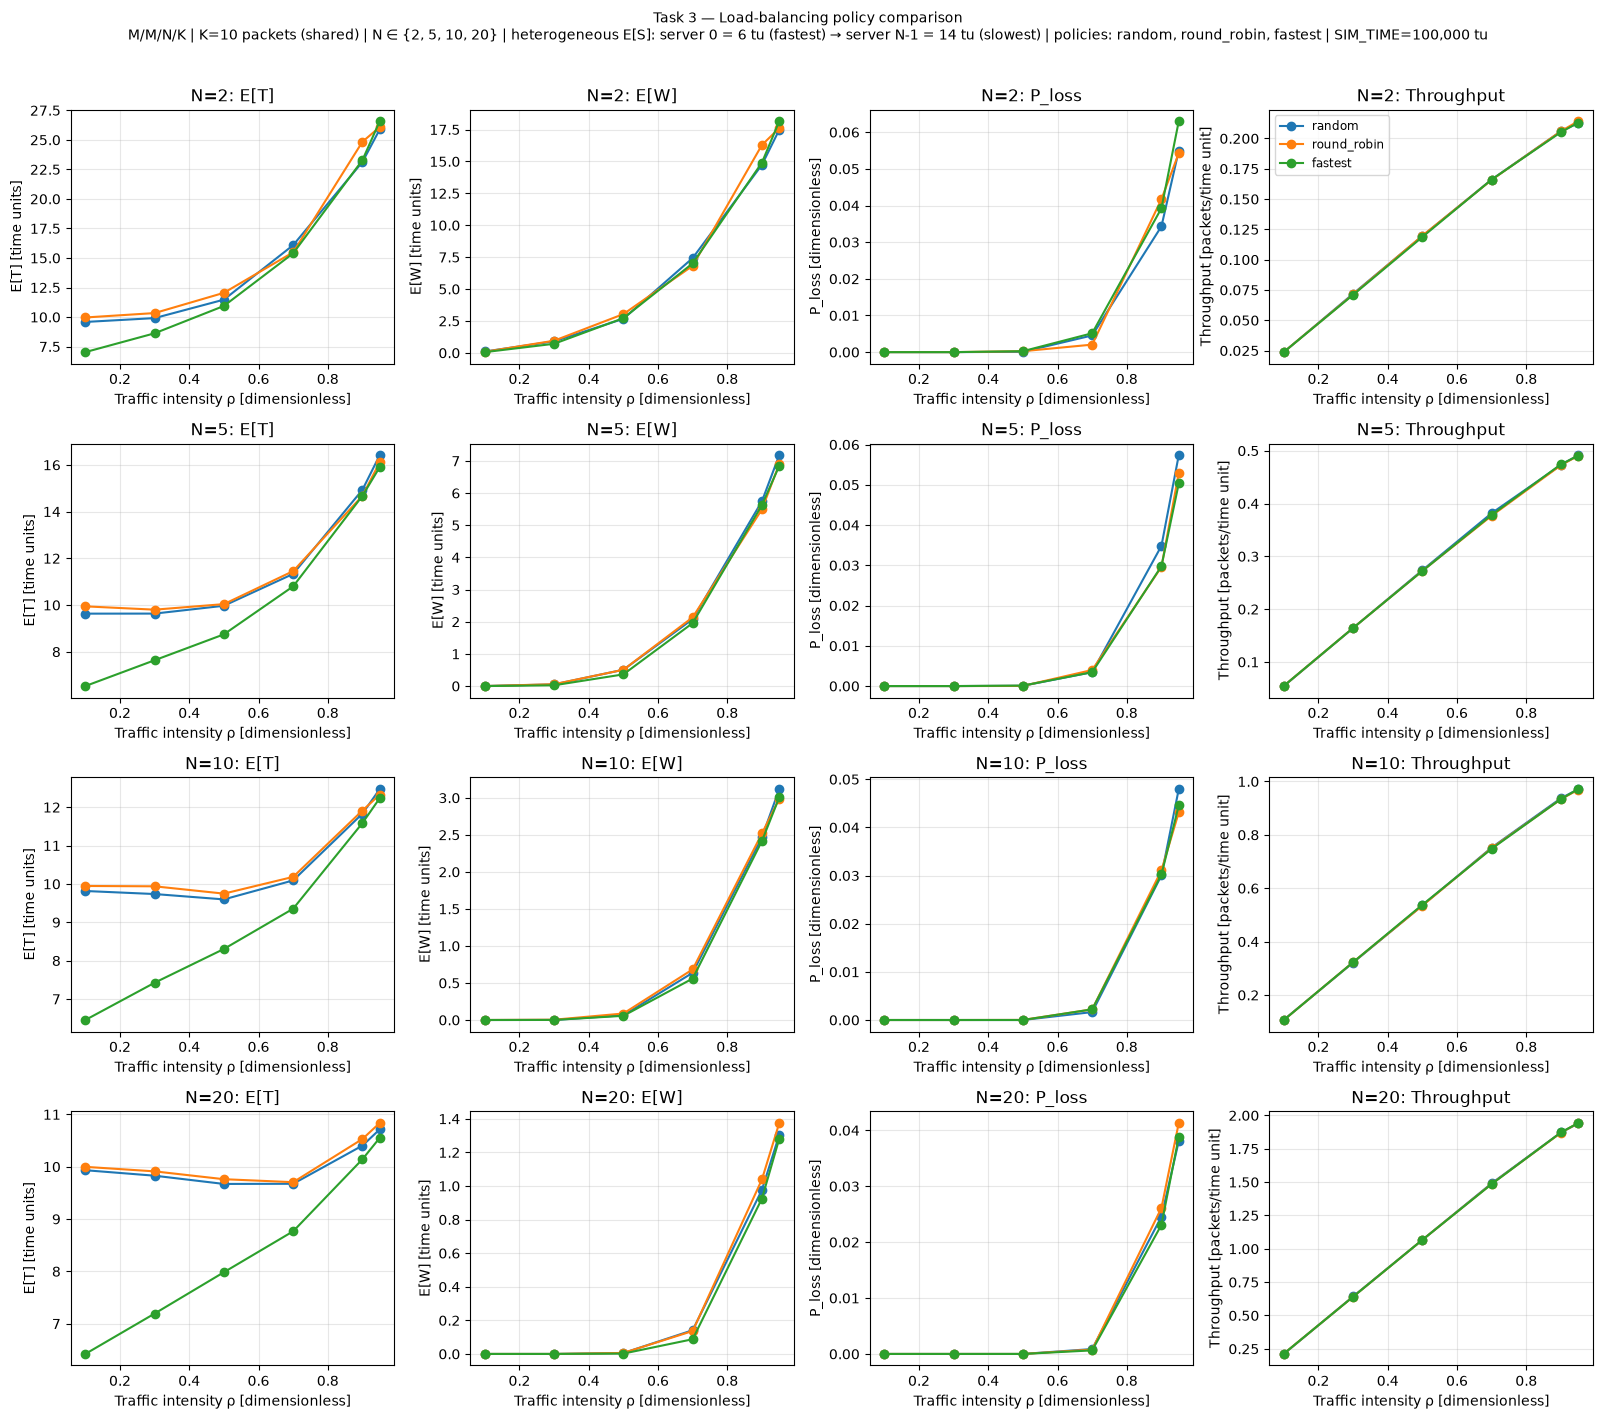

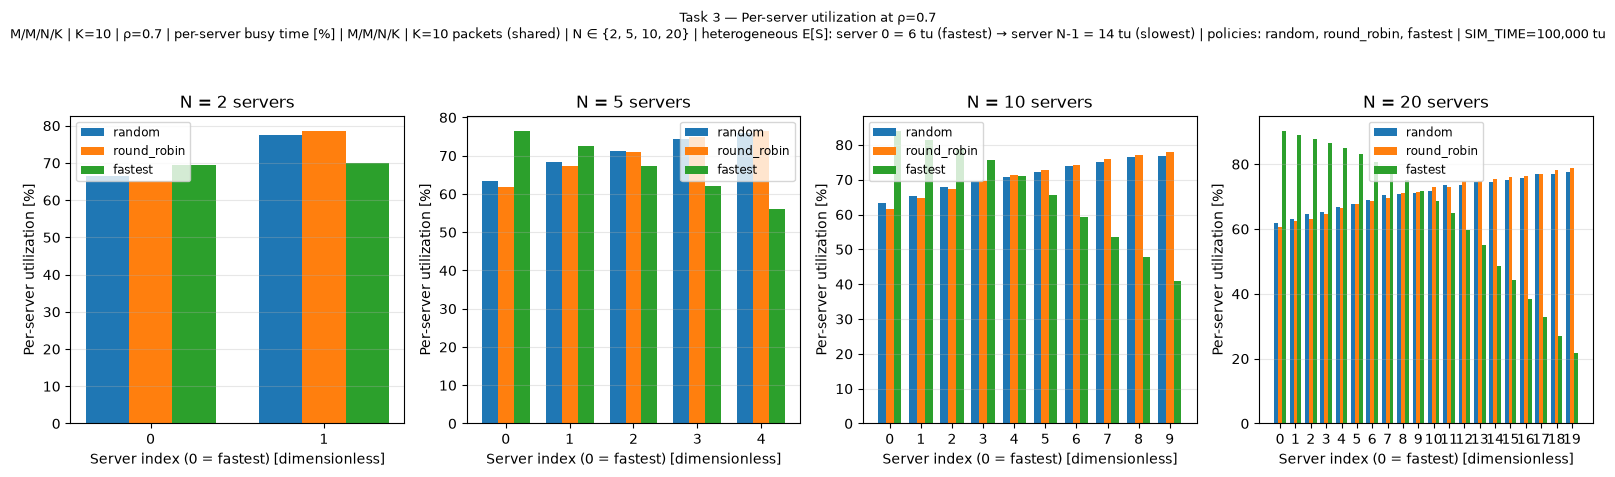


Per-server utilization [%] at ρ = 0.7

N = 2
  random       [66.4, 77.4]
  round_robin  [65.0, 78.7]
  fastest      [69.4, 69.9]

N = 5
  random       [63.3, 68.5, 71.3, 74.2, 75.9]
  round_robin  [61.7, 67.2, 71.0, 74.9, 76.3]
  fastest      [76.6, 72.4, 67.4, 62.1, 56.0]

N = 10
  random       [63.2, 65.4, 68.0, 69.6, 70.7, 72.3, 73.9, 75.0, 76.5, 76.9]
  round_robin  [61.7, 64.7, 67.2, 69.7, 71.4, 72.9, 74.2, 76.0, 77.1, 78.0]
  fastest      [84.1, 81.3, 78.7, 75.6, 71.0, 65.5, 59.2, 53.7, 47.8, 41.0]

N = 20
  random       [62.0, 63.1, 64.6, 65.2, 66.8, 67.7, 69.1, 70.5, 70.8, 71.1, 71.8, 73.5, 73.6, 74.6, 74.6, 75.2, 75.6, 76.9, 77.1, 77.6]
  round_robin  [60.6, 62.3, 63.2, 64.7, 66.6, 67.6, 68.6, 69.5, 71.0, 71.6, 73.0, 73.0, 74.7, 74.8, 75.5, 76.1, 76.3, 76.9, 78.1, 78.9]
  fastest      [90.3, 89.2, 87.8, 86.6, 85.0, 83.1, 80.8, 78.2, 75.1, 71.7, 68.8, 65.1, 59.6, 54.9, 48.7, 44.2, 38.5, 33.0, 27.0, 21.6]


In [2]:
# ******************************************************************************
# Performance plots — Task 3
# ******************************************************************************
CFG_3 = (
    f"M/M/N/K | K={K} packets (shared) | N ∈ {{2, 5, 10, 20}} | "
    f"heterogeneous E[S]: server 0 = 6 tu (fastest) → server N-1 = 14 tu (slowest) | "
    f"policies: random, round_robin, fastest | SIM_TIME={SIM_TIME:,} tu"
)
METRIC_Y = {
    'et': 'E[T] [time units]', 'ew': 'E[W] [time units]',
    'loss': 'P_loss [dimensionless]', 'tp': 'Throughput [packets/time unit]',
}

metric_keys = [('et', 'E[T]'), ('ew', 'E[W]'), ('loss', 'P_loss'), ('tp', 'Throughput')]

fig, axs = plt.subplots(len(N_LIST), len(metric_keys), figsize=(16, 3.5 * len(N_LIST)))
fig.suptitle(f'Task 3 — Load-balancing policy comparison\n{CFG_3}', fontsize=10, y=1.01)

for row, n in enumerate(N_LIST):
    for col, (key, title) in enumerate(metric_keys):
        ax = axs[row, col]
        for pol in POLICIES:
            vals = [r[key] for r in results[n][pol]]
            ax.plot(LOAD_LEVELS, vals, 'o-', label=pol)
        ax.set_title(f'N={n}: {title}')
        ax.set_xlabel('Traffic intensity ρ [dimensionless]')
        ax.set_ylabel(METRIC_Y[key])
        ax.grid(True, alpha=0.3)
        if row == 0 and col == len(metric_keys) - 1:
            ax.legend(fontsize='small')

plt.tight_layout()
plt.savefig('task3_performance.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Per-server utilization at rho = 0.7 ---
RHO_SHOW = 0.7
rho_idx = LOAD_LEVELS.index(RHO_SHOW)
CFG_3B = f"M/M/N/K | K={K} | ρ={RHO_SHOW} | per-server busy time [%] | {CFG_3}"

fig2, axs2 = plt.subplots(1, len(N_LIST), figsize=(4 * len(N_LIST), 4.5))
fig2.suptitle(f'Task 3 — Per-server utilization at ρ={RHO_SHOW}\n{CFG_3B}', fontsize=9, y=1.05)

for ax, n in zip(axs2, N_LIST):
    x = list(range(n))
    width = 0.25
    for j, pol in enumerate(POLICIES):
        utils = [u * 100 for u in results[n][pol][rho_idx]['util']]
        ax.bar([xi + j * width for xi in x], utils, width, label=pol)
    ax.set_xlabel('Server index (0 = fastest) [dimensionless]')
    ax.set_ylabel('Per-server utilization [%]')
    ax.set_title(f'N = {n} servers')
    ax.set_xticks([xi + width for xi in x])
    ax.set_xticklabels([str(i) for i in x])
    ax.legend(fontsize='small')
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('task3_load_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nPer-server utilization [%] at ρ = {RHO_SHOW}")
print('=' * 80)
for n in N_LIST:
    print(f"\nN = {n}")
    for pol in POLICIES:
        utils = [round(u * 100, 1) for u in results[n][pol][rho_idx]['util']]
        print(f"  {pol:<12} {utils}")


## Task 3: Observations and Conclusions

### Simulation configuration
| Parameter | Value |
|-----------|-------|
| Model | **M/M/N/K** (Poisson arrivals, exponential service) |
| Servers $N$ | 2, 5, 10, 20 |
| Shared buffer $K$ | **10 packets** |
| Service times | Heterogeneous: server 0 = **6 tu** (fastest) → server $N{-}1$ = **14 tu** (slowest), linear spread |
| Policies | `random`, `round_robin`, `fastest` (shortest-queue-to-fastest-server) |
| $\rho$ | $\lambda / \sum_i \mu_i$ |
| `SIM_TIME` | 100,000 tu |

### Graph configuration
- **Figure 1:** $E[T]$, $E[W]$ [tu]; $P_{loss}$ [dimensionless]; TP [pkt/tu] vs **ρ** for each $N$ and policy.
- **Figure 2:** Per-server utilization **[%]** at **ρ = 0.7**; x-axis = server index (0 = fastest).

### Key performance trends

**Policy ranking (delay):** **Fastest-server** → lowest $E[T]$ and $E[W]$ at low–medium $\rho$, because work is steered to the 6-tu server when idle. **Random** and **round_robin** ignore speed → more packets served by slow (14-tu) servers → higher delay and $E[N_q]$.

**Saturation:** At $\rho \geq 0.9$, all policies converge: servers busy, buffer full ($K=10$), **$P_{loss}$** rises. Assignment policy matters less under heavy congestion.

**Effect of $N$:** More servers increase capacity and lower per-server load, but with fixed $K=10$ the **shared buffer becomes the bottleneck** at high $\rho$ regardless of policy.

### Load distribution (ρ = 0.7)

| Policy | Utilization pattern |
|--------|---------------------|
| **Fastest** | Server 0 (fastest) highest **[%]** busy; slow servers as overflow |
| **Random** | Roughly balanced arrivals; slow servers still show higher utilization (longer service) |
| **Round robin** | More even job assignment; utilization skew persists at high load |

### Theoretical justification
Shortest-processing-time / fastest-server routing minimizes mean delay in heterogeneous systems when servers are idle (classic scheduling result). Random/RR achieve **fairer load** at the cost of **higher mean sojourn time**. Finite $K$ introduces loss — consistent with M/M/N/K behaviour.

### Conclusion
- **Minimize latency:** use **fastest-server** policy.
- **Balance heterogeneous hardware:** use **round_robin** or **random**.
- With **$K=10$**, all policies eventually drop packets at high $\rho$; faster routing delays saturation by draining the queue more quickly.
